# How to Run
1. Begin by setting the granularity to 'q'. (change the accessed element in the list to 0)
2. Set run_every_query to True
3. Update max_quarter and max_month
4. Run All
5. Set the granularity to 'm'. (change the accessed element in the list to 1)
6. Set run_every_query to False and build_ms_df_from_scratch to True
7. Restart Kernel and Run All

In [1]:
import pandas as pd
import numpy as np
import pyodbc
import pickle
import warnings
import time
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
tqdm.pandas()
pd.set_option('display.max_columns', 100)
pd.set_option('display.min_rows', 100)
import openpyxl
import datetime as dt
import re
import os
import copy

In [40]:
granularity = ['q', 'm','w'][1]
run_every_query = False
max_quarter, max_month = 1, 3
max_week = dt.date.today().strftime("%U")
max_week = int(max_week)

In [41]:
def vintage_to_float(vintage):
    """
    Converts a vintage of form 'YYYY QQ' (i.e. '2016 Q2') to a float (i.e. 2016.25)
    The vectorized form of this function for a Series is: pd.to_numeric(df.vintage.str[:4]) + (pd.to_numeric(df.vintage.str[-1]) - 1) / 4
    NOTE: The following formula has been modified to allow for vintages of the form 'YYYY MMM' (i.e. '2016 M06')
    """
    if vintage[5]=='Q':
        return int(vintage[:4]) + (int(vintage[-1]) - 1) / 4
    elif vintage[5]=='M':
        return int(vintage[:4]) + (int(vintage[-2:]) - 1) / 12
    

def float_to_vintage(vintage_float):
    """
    Converts a vintage as a float (i.e. 2016.25) to a str of form 'YYYY QQ' (i.e. '2016 Q2')
    The vectorized form of this function for a Series is: 
        df.vintage_float.astype(int).astype(str) + ' Q' + ((df.vintage_float % 1) * 4 + 1).astype(int).astype(str)
    """
    return str(int(vintage_float)) + ' Q' + str(int((vintage_float % 1) * 4 + 1))
    
"""
SQL and Files
"""
def run_sql(filename, sub_list=[], connection=None, filename_is_query=False):
    """
    Run a SQL Query by reading from a .txt file, substituting values when required.
    Input:
    filename (str): File that we want to read. Usually a .txt file.
    sub_list (list of (str,str) tuples): Substitute each instance of the first element of the tuple for the second.
                                         Example: [('{max_mob}', '6')]
    """
    if filename_is_query:
        query = filename
    else:
        with open(filename, 'r') as file:
            query = file.read()
    for sub in sub_list:
        text, var = sub
        query = query.replace(text, var)
#     print(query)
    if connection is None:
        with pyodbc.connect("DSN=Redshift_prod") as conn:
            warnings.filterwarnings("ignore", category=UserWarning)
            df = pd.read_sql_query(sql=query, con=conn)
            warnings.filterwarnings("default", category=UserWarning)
            return df
    else:
        warnings.filterwarnings("ignore", category=UserWarning)
        df = pd.read_sql_query(sql=query, con=connection)
        warnings.filterwarnings("default", category=UserWarning)
        return df

def store_pickle(data, filename):
    """
    Stores a pickle of the given data at the given filename, in a simplified function call
    """
    # Perform a swap if I got the order of data and filename backwards
    if type(data)==str:
        temp = filename
        filename = data
        data = temp
    with open(filename, 'wb') as file:
        pickle.dump(data, file)

def get_pickle(filename):
    """
    Loads a pickle in a simplified function call
    """
    with open(filename, 'rb') as file:
        data = pickle.load(file)
    return data

def smooth(series):
    """
    Calculates a centered average by averaging the previous two values and following two values, as well as the current value.
    Handles the first and last two values separately.
    """
    averaged_series = pd.Series(index=series.index, dtype=float)  # Create an empty Series to store the averaged values
    
    # Handle the first value separately
    averaged_series.iloc[0] = series.iloc[0]
    averaged_series.iloc[1] = (series.iloc[0] + series.iloc[1] + series.iloc[2]) / 3
    
    # Calculate the running average for the middle values
    for i in range(2, len(series) - 2):
        averaged_series.iloc[i] = (series.iloc[i-2] + series.iloc[i-1] + series.iloc[i] + series.iloc[i+1] + series.iloc[i+2]) / 5
    
    # Handle the last value separately
    averaged_series.iloc[-1] = series.iloc[-1]
    averaged_series.iloc[-2] = (series.iloc[-1] + series.iloc[-2] + series.iloc[-3]) / 3
    
    return averaged_series
def weight_by_proceeds(metric, proceeds):
    """
    Function to get the average of a given Series, weighted by Amount Financed.
    """
    return (metric * proceeds).sum() / proceeds.sum()
def weighted_average_and_sum(group, metrics):
    """
    Function that gets the weighted average of a Series (or several series), 
        returning the averages and the sum of Amount Financed.
    """
    if type(metrics)==str:
        weighted_avg = (group[metrics] * group.amt_financed).sum() / group.amt_financed.sum()
        return pd.Series({metrics: weighted_avg, 'amt_financed': group.amt_financed.sum()})
    result_dict = {'amt_financed': group.amt_financed.sum()}
    for metric in metrics:
        weighted_avg = (group[metric] * group.amt_financed).sum() / group.amt_financed.sum()
        result_dict[metric] = weighted_avg.sum()
    return pd.Series(result_dict)

# Old Recovery Model

In [42]:
def auc_pred(rra_df, leave_out, rra_lob_df=None):
    """
    Recovery model used by the pricing team to determine the expected recovery of a vehicle when it is sold.
    KMX uses a different recovery model, so it's handled separately.
    This function was made to support "Leave Out" analysis, which isn't included in the Ragu jar. 
        That's what all the if/else statements are for.
    This function has been vectorized as much as possible, but it's possibly not totally optimized.
    Inputs:
        rra_df (pd.DataFrame object): Data containing vehicle info. Each row is a vehicle, and each row is analyzed separately.
        leave_out (str): Factor to not consider in this runthrough. Helps us understand how much of a role each factor plays.
        rra_lob_df (pd.DataFrame): Only used in Leave Out analysis. Contains every vehicle for every vintage for this LOB.
    Outputs:
        recovery_multiplier (pd.Series): Column to add to rra_df containing the % of original vehicle value we expect to recover.
    """
    if len(rra_df[rra_df.lob=='KMX']) > 0:
        conditions = [
            (rra_df.car_age_orig < 3),
            (rra_df.car_age_orig == 3) & (rra_df.sale_price < 30000),
            (rra_df.car_age_orig == 3) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (rra_df.car_age_orig == 3) & (rra_df.sale_price >= 40000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (rra_df.sale_price < 30000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (rra_df.sale_price >= 40000),
            (rra_df.car_age_orig >= 6) & (rra_df.sale_price < 30000),
            (rra_df.car_age_orig >= 6) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (rra_df.car_age_orig >= 6) & (rra_df.sale_price >= 40000)
        ]

        values = [3300, 3700, 5400, 7200, 4700, 6400, 8200, 5700, 7400, 9200]

        recovery_amount = np.maximum(0, rra_df.sale_price - np.select(conditions, values, default=0))

        return recovery_amount * (1 - 0.206) ** rra_df.yob / rra_df.sale_price
    rra_df['coef_intercept'] = 0.0891185245
    rra_df['coef_yob'] = -0.2668087106 * rra_df.yob
    if leave_out != 'Mileage/age':
        rra_df['coef_mlg_x_age'] = 0.0001463508 * rra_df.car_age_orig * rra_df.mileage - 0.0004310013 * rra_df.car_age_orig - 0.0033127224 * rra_df.mileage
    else: 
        rra_df['coef_mlg_x_age'] = np.log((np.exp(0.0001463508 * rra_lob_df.car_age_orig * rra_lob_df.mileage) * np.exp(-0.0004310013 * rra_lob_df.car_age_orig) * np.exp(-0.0033127224 * rra_lob_df.mileage)).mean())
    if leave_out != 'Japanese':
        rra_df['coef_japanese'] = rra_df.car_japanese.map({'Japanese': 0.1004702010, 'Other': 0})
    else:
        rra_df['coef_japanese'] = np.log(rra_lob_df.car_japanese.map({'Japanese': np.exp(0.1004702010), 'Other': np.exp(0)}).mean())
    if leave_out != 'Vehicle class':
        rra_df['coef_class'] = rra_df.car_class_only.map({'Compact': 0.0303893787,
                                        'Minivan': np.log(0.975),
                                        'Sporty': 0.0758593720,
                                        'SUV Large': -0.0237364286,
                                        'SUV Small': 0.0190370746,
                                        'Work Van': 0,
                                        'Truck': 0.1436074633,
                                        'Car': 0, 'Other':0})
    else:
        rra_df['coef_class'] = np.log(rra_lob_df.car_class_only.map({'Compact': np.exp(0.0303893787),
                                                             'Minivan': np.exp(np.log(0.975)),
                                                             'Sporty': np.exp(0.0758593720),
                                                             'SUV Large': np.exp(-0.0237364286),
                                                             'SUV Small': np.exp(0.0190370746),
                                                             'Work Van': np.exp(0),
                                                             'Truck': np.exp(0.1436074633),
                                                             'Car': np.exp(0), 'Other':np.exp(0)}).mean())
    if leave_out != 'Fuel type':
        rra_df['coef_fuel'] = rra_df.fuel_type.map({'Hybrid': -0.0315481529,
                                       'Flex': 0.0255682747,
                                       'Diesel': -0.1284314925,
                                       'EV': np.log(0.9),
                                       'Gas': 0})
    else:
        rra_df['coef_fuel'] = np.log(rra_lob_df.fuel_type.map({'Hybrid': np.exp(-0.0315481529),
                                                    'Flex': np.exp(0.0255682747),
                                                    'Diesel': np.exp(-0.1284314925),
                                                    'EV': np.exp(np.log(0.9)),
                                                    'Gas': np.exp(0)}).mean())
    if leave_out != 'Luxury classification':
        rra_df['coef_lux'] = rra_df.car_lux.map({'Luxury': -0.1108317813, 'Standard': 0})
    else:
        rra_df['coef_lux'] = np.log(rra_lob_df.car_lux.map({'Luxury': np.exp(-0.1108317813), 'Standard': np.exp(0)}).mean())
    if leave_out != 'LOB':
        rra_df['coef_lob'] = rra_df.lob.map({'ENT': 0.0405731662,
                                      'FLD': 0.0405731662,
                                      'FRN': -0.0277901296,
                                      'STG': 0.0263749504,
                                      'AN': 0})
    else:
        rra_df['coef_lob'] = np.log(rra_lob_df.lob.map({'ENT': np.exp(0.0405731662),
                                              'FLD': np.exp(0.0405731662),
                                              'FRN': np.exp(-0.0277901296),
                                              'STG': np.exp(0.0263749504),
                                              'AN': np.exp(0)}).mean())
    if leave_out != 'Driver flag':
        rra_df['coef_driver'] = (-0.0918049638) * rra_df.driver_flag
    else:
        rra_df['coef_driver'] = np.log(rra_lob_df.driver_flag.map({1:np.exp(-0.0918049638), 0: np.exp(0)}).mean())
    if leave_out != 'Impound probability':
        rra_df['coef_impound'] = (-0.2803330880) * rra_df.impound_prob
    else:
        rra_df['coef_impound'] = np.log(np.mean(np.exp((-0.2803330880) * rra_lob_df.impound_prob)))
    
    try:
        # code that may raise an exception
        for col in ['coef_intercept', 'coef_yob', 'coef_mlg_x_age', 'coef_japanese', 'coef_class', 'coef_fuel', 'coef_lux', 
                    'coef_lux', 'coef_lob', 'coef_driver', 'coef_impound']:
            print(col)
            assert len(rra_df)==len(rra_df.dropna(subset=col))
    except Exception as e:
        # code to handle the exception
        print(col, ';', rra_df.fuel_type.unique())
        print(len(rra_df) - len(rra_df.fuel_type.dropna()))
        print(rra_df)
        store_pickle('rra_df_pickle_exception',rra_df)
        raise Exception()

    return rra_df.r_mmi * np.exp(rra_df.coef_intercept + rra_df.coef_yob + rra_df.coef_mlg_x_age + rra_df.coef_japanese\
                                 + rra_df.coef_class + rra_df.coef_fuel + rra_df.coef_lux + rra_df.coef_lob\
                                 + rra_df.coef_impound + rra_df.coef_driver)

In [43]:
def get_ula_multiplier_nonkmx(ula_df, leave_out):
    ula_df['loss_multiplier'] = 1
    if leave_out!='Previous ACA chargeoff':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.prev_co_flag # loss_adj_01_acaco: 1 or 1.1
    if leave_out!='Small amount financed':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.small_amt_financed_flag *(1- ula_df.pricing_change_flag) # loss_adj_02_small_amtfin: 1 or 1.1
    if leave_out!='Zero cash down':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.zero_cash_down_flag * (1 - ula_df.pricing_change_flag) # loss_adj_03_zero_down: 1 or 1.1
    if leave_out!='High mileage vehicle':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_mileage_vehicle_flag # loss_adj_04_high_mileage: 1 or 1.1
    if leave_out!='High PTI':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_pti_flag * (1 - ula_df.pricing_change_flag) # loss_adj_05_high_PTI: 1 or 1.1
    if leave_out!='Car make':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.car_make_penalty_flag\
                                    - 0.1 * ula_df.car_make_benefit_flag - 0.1*ula_df.pricing_change_flag*ula_df.car_make_benefit_flag\
                                    +  0.1*ula_df.pricing_change_flag*ula_df.car_make_benefit_flag*ula_df.ent_fld_flag # loss_adj_06_vehicle_make: 1 or 0.9 or 1.1
    if leave_out!='Theft risk':
        ula_df.loss_multiplier *= 0.987 + 0.099 * ula_df.theft_risk_flag * (1-ula_df.pricing_change_flag) + 0.013*ula_df.pricing_change_flag  # loss_adj_09_theft_risk: 0.987 or 1.086
    if leave_out!='MCY high model score, low mileage':
        ula_df.loss_multiplier *= 1 - 0.2 * ula_df.mcy_low_mileage_flag # loss_adj_07_new_MCY: 1 or 0.8
    if leave_out!='Weekday/weekend decision':
        ula_df.loss_multiplier *= 1 - 0.05 * ula_df.weekend_flag\
                                    + 0.02 * ula_df.weekday_flag # loss_adj_08_day_of_week: 1 or 0.95 or 1.02
    if leave_out!='Secured credit (Chime, etc.)':
        ula_df.loss_multiplier *= 0.989 + 0.111 * ula_df.secured_credit_flag # loss_adj_10_secured_card: 0.989 or 1.1
    if leave_out!='Employment type':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.seasonal_employment_flag\
                                    - 0.1 * ula_df.waiter_employment_flag # loss_adj_11_employment: 1 + 0.1 * cust_attr$employment_flag
    if leave_out!='Authorized tradelines':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.nonkmx_auth_tradelines_flag # loss_adj_13_authorized_tradeline: 1 or 1.1
    if leave_out!='Null FICO with Vantage':
        ula_df.loc[ula_df['fico_adjustment_flag'] == 1, 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.null_fico_w_vantage_flag # loss_adj_14_non_fico: 0.99 or 1.1
    if leave_out!='Dealer Level (Non-KMX)':
        ula_df.loss_multiplier *= ula_df.pricing_scalar
    if leave_out!='Clip':
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.7, 1.4)
    # if leave_out!='Dealer Level (Non-KMX)':
    #     ula_df.loss_multiplier *= 1 - 0.2 * (ula_df.lob_or_bucket == 'A').astype(int) \
    #                                 - 0.1 * (ula_df.lob_or_bucket == 'B').astype(int) \
    #                                 + 0.09 * (ula_df.lob_or_bucket == 'D').astype(int) \
    #                                 + 0.2 * (ula_df.lob_or_bucket == 'E').astype(int)
        #change for lob dll ragu
    # The following is a pricing adjustment, but we don't include it, since it's macroeconimic (that's what the loss committee predicts)
#       #Additional loss adjustment to ensure losses match loss committe predictions
#   lob_scalar <- ifelse(app_attr$lob == "AN", 1.045,
#                        ifelse(app_attr$lob == "FLD", 1.09,
#                               ifelse(app_attr$lob == "FRN", 0.925,
#                                      ifelse(app_attr$lob == "STG", 0.996, 1))))
    return ula_df

In [44]:
def get_ula_multiplier_kmx(ula_df, loss_scale=0.067, leave_out='None'):
    ula_df['loss_multiplier'] = 1
    if leave_out!='Job time':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + 0.2 * ula_df.job_time_flag
    if leave_out!='Low FICO':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_fico_flag & ~ula_df.high_model_score_flag)\
                                    + loss_scale * (ula_df.low_fico_flag & ula_df.high_model_score_flag)
    if leave_out!='Low Vantage':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_vantage_flag & ~ula_df.high_model_score_flag)\
                                    + loss_scale * (ula_df.low_vantage_flag & ula_df.high_model_score_flag)
    if leave_out!='Louisiana':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + 0.35 * ula_df.louisiana_flag
    if leave_out!='High PTI':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + 0 * ula_df.normal_pti_flag \
                                    + 0.05 * ula_df.high_pti_tier_1_flag \
                                    + 0.1 * ula_df.high_pti_tier_2_flag \
                                    + (1.4 * (1 + loss_scale) - 1) * ula_df.high_pti_tier_3_flag
    if leave_out!='Existing DQ':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + 0.1 * ula_df.existing_dq_flag
    if leave_out!='Employment type':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag
    ula_df.loss_multiplier /= (1 + loss_scale)
    if leave_out!='Secured credit (Chime, etc.)':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + (-0.01 + 0.06 * ula_df.secured_credit_flag)\
                                        * ~(~ula_df.job_time_flag & ula_df.narrowed_soft_pull_flag & ula_df.secured_credit_flag)
    if leave_out!='Authorized tradelines':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 0.99 + 0.18 * ula_df.kmx_auth_tradelines_flag
    if leave_out!='Null FICO with Vantage':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 0.99 + 0.11 * ula_df.null_fico_w_vantage_flag + 0.01 * ula_df.null_fico_null_vantage_flag
    if leave_out!='Soft pull':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + ~ula_df.job_time_flag * (~ula_df.narrowed_soft_pull_flag * -0.025
                                                               + ula_df.narrowed_soft_pull_flag * (~ula_df.secured_credit_flag * 0.108
                                                                                                   + ula_df.secured_credit_flag * 0.295))
    if leave_out!='Clip':
        clipped_multiplier = np.clip(ula_df[~ula_df.high_pti_tier_3_flag].loss_multiplier, 0.8, 1.35 / (1 + loss_scale))
        ula_df.loc[~ula_df.high_pti_tier_3_flag & ~ula_df.mtn_3_1_flag , 'loss_multiplier'] = clipped_multiplier
    if leave_out!='Vehicle Age':
        ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier']  *= 0.8593 + 0.0201 * ula_df.continuous_vehicle_age
    
    
    #Mountain 3.1 Gross Loss Adjustments
    
    if leave_out!='Louisiana':
        ula_df.loc[ula_df.mtn_3_1_flag,'loss_multiplier']  *= 1 + 0.35 * ula_df.louisiana_flag
    if leave_out!='Authorized tradelines':
        ula_df.loc[ula_df.mtn_3_1_flag,'loss_multiplier'] *= 0.99 + 0.06 * ula_df.kmx_auth_tradelines_flag
    if leave_out!='Soft pull':
        ula_df.loc[ula_df.mtn_3_1_flag & ula_df.soft_pull_flag,'loss_multiplier'] *= 1.1 * (0.97 + 0.23*ula_df.secured_credit_flag) * (0.995 + 0.03*ula_df.low_bureau_flag) * (0.97 + 0.15*ula_df.cd_perc_flag) * (0.978 + 0.172*ula_df.open_tl_flag)
        ula_df.loc[ula_df.mtn_3_1_flag & ~ula_df.soft_pull_flag,'loss_multiplier'] *= 1 * (0.98 + 0.32*ula_df.secured_credit_flag) * (0.9767 + 0.2233*ula_df.low_bureau_flag)* (0.954 + 0.346*ula_df.cd_perc_flag) * (0.945 + 0.405*ula_df.open_tl_flag )
    ula_df.loc[ula_df.mtn_3_1_flag,'loss_multiplier']/=1.1
    if leave_out!='Clip':
        clipped_multiplier = np.clip(ula_df[ula_df.mtn_3_1_flag].loss_multiplier, 0.75, 1.4)
        ula_df.loc[ula_df.mtn_3_1_flag , 'loss_multiplier'] = clipped_multiplier
    
    return ula_df

In [45]:
def get_ragu_score(vintage, lob, lob_type, ula_df_total, rra_df_total, leave_out='None'):
    """
    This function provides the core of RAGU Score analysis.
    There are three parts to this code:
        1. Get Unit Loss Adjustments: Modify the probability of chargeoff based on factors not included in Model Score.
        2. Get Recovery Rate Adjustments: Use auc_pred() to calculate how much we'll recover if the vehicle sells.
        3. Group it all together: Group based on granularity, applying the RAGU Score calculation formulas (see PowerPoint).
            This section rolls up by LOB, but if there are multiple LOBs (for non_kmxent), group by that in addition.
    Inputs:
        vintage (str): Monthly or quarterly vintage (for example, "2022 M03" or "2022 Q1") we want results for
        lob (str or tuple of str): LOB we want results for. 
            If multiple are provided, they are assessed in the context of each other, but still separate.
        lob_type (str): Higher-order group. For KMX and ENT, this is the same as LOB, but for other LOBs, this is 'non_kmxent'
        ula_df_total (pd.DataFrame object): DataFrame containing every vehicle's ULA-related info throughout ACA history.
        rra_df_total (pd.DataFrame object): DataFrame containing every vehicle's RRA-related info throughout ACA history.
        leave_out (str): For Leave Out analysis, what factor to leave out. This helps us assess how much impact each factor has.
    Outputs:
        full_df (pd.DataFrame): DataFrame containing the results of RAGU Score analysis for the given vintage and LOB(s). 
            All columns are weighted averages unless otherwise noted.
            Columns: 'amt_financed_x': Sum of amount financed for this grouping
                     'loss_multiplier': Result of ULA.  What % more or less the unit loss rate should be.
                     'recovery_unadjusted_multiplier': % of original vehicle value we expect to recover, not adjusted for LTV or baseline.
                     'ltv': LTV of grouping
                     'bbvalue': BlackBook value of grouping. For KMX, this is sale price instead.
                     'ltv_realization_factor': Unused. Factor to determine how much benefit from LTV we're seeing.
                     'recovery_100_ltv_multiplier': Unused. recovery_unadjusted_multiplier adjusted for LTV, assuming 100% impact.
                     'recovery_multiplier': Unused. recovery_unadjusted_multiplier adjusted for LTV, after ltv_realization_factor.
                     'vintage': Vintage for this grouping.
                     'model_score': Model score for this grouping. Same as ms_original.
                     'amt_financed_y': Unused. Sum of amount financed for this grouping, using different parts of ms_df. Nearly the same as amt_financed_x.
                     'est_unit_loss': Probability of chargeoff. Currently set to mean_unit_loss. We may eventually modify this to convert the Unit Loss Score to a Unit Loss %.
                     'unit_loss_score': Model Score adjusted for ULA.
                     'ms_original': Model score for this grouping. Same as model_score (for the moment, this may change when we get better historical values for the current model).
                     'baselined_recovery': recovery_multiplier / baseline_recovery_pct. How much better/worse we're doing for this grouping compared to the grouping's baseline.
                     'baselined_unadjusted_recovery': recovery_unadjusted_multiplier / baseline_recovery_unadjusted_pct
                     'baselined_100_ltv_recovery': recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct
                     'ms_gla': Renamed Unit Loss Score
                     'ms_exclude_ltv': RAGU Score without any LTV impacts. Because we have some issues with LTV, this is the score we use, taking LTV adjustments in the Excel.
                     'ms_100_ltv': RAGU Score assuming 100% LTV impacts.
                     'ragu_score': RAGU Score using baselined_recovery. Uses the RAGU formulas.
    """
    # Get the Unit Loss Adjustment Multiplier
    if type(lob)==str:
        ula_df = ula_df_total[(ula_df_total.vintage==vintage)&(ula_df_total.lob==lob)].copy()
        ula_lob_df = ula_df_total[(ula_df_total.lob==lob)].copy()
    else:
        ula_df = ula_df_total[(ula_df_total.vintage==vintage)&(ula_df_total.lob.isin(lob))].copy()
        ula_lob_df = ula_df_total[(ula_df_total.lob.isin(lob))].copy()
    if lob == 'KMX':
        loss_scale = 0.067
        ula_df = get_ula_multiplier_kmx(ula_df, loss_scale, leave_out)
    else:
        ula_df = get_ula_multiplier_nonkmx(ula_df, leave_out)
    ula_df = ula_df[['account_number', 'book_date', 'bbvalue', 'sale_price', 'amt_financed', 'lob_or_bucket', 'lob', 'loss_multiplier']]
    # Get the Recovery Rate Adjustment Multiplier
    if leave_out == 'None':
        if type(lob)==str:
            rra_df = rra_df_total[(rra_df_total.vintage==vintage)&(rra_df_total.lob==lob)].copy()
        else:
            rra_df = rra_df_total[(rra_df_total.vintage==vintage)&(rra_df_total.lob.isin(lob))].copy()
    else:
        if type(lob)==str:
            rra_df = rra_df_total[(rra_df_total.lob==lob)].copy()
        else:
            rra_df = rra_df_total[(rra_df_total.lob.isin(lob))].copy()
    try:
        rra_df.car_year = rra_df.car_year.fillna(round(rra_df.car_year.mean()))
    except:
        store_pickle('rra_df_pickle_exception',rra_df)
    # Note: ceil(car_age_orig) = ula_df's vehicle_age column
    rra_df['car_age_orig'] = np.maximum((pd.to_datetime(rra_df.book_date) - pd.to_datetime(rra_df.car_year.astype(int).astype(str) + '-09-01')).dt.days / 365, 1 / 365)
    if leave_out == 'None':
        rra_df['recovery_multiplier'] = auc_pred(rra_df, leave_out)
    else:
        rra_lob_df = rra_df.copy()
        rra_df = rra_df[rra_df.vintage==vintage]
        rra_df['recovery_multiplier'] = auc_pred(rra_df, leave_out, rra_lob_df)
    rra_df = rra_df[['account_number', 'recovery_multiplier']]
    mix_df = ula_df.merge(rra_df, on='account_number', how='inner').drop_duplicates(subset='account_number', keep='first')
    bb_populated_df = mix_df.dropna(subset='bbvalue')
    bb_populated_df['ltv'] = bb_populated_df.amt_financed / bb_populated_df.bbvalue
    bb_populated_df['recovery_unadjusted_multiplier'] = skip_rate * bb_populated_df.recovery_multiplier.copy()
    # Group by LOB
    grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])
    # Calculate these values after rollup to match the LTV graph better.
    grouped_mix_df['ltv_realization_factor'] = 0 # 1 - ltv_realization_dollar / (grouped_mix_df.recovery_unadjusted_multiplier * grouped_mix_df.bbvalue)
    grouped_mix_df['recovery_100_ltv_multiplier'] = 0 # (grouped_mix_df.recovery_unadjusted_multiplier * baseline_ltv / grouped_mix_df.ltv).copy()
    grouped_mix_df['recovery_multiplier'] = 0 # grouped_mix_df.recovery_unadjusted_multiplier * (1 + (baseline_ltv / grouped_mix_df.ltv - 1) * grouped_mix_df.ltv_realization_factor)
    vintage_ms_df = ms_df[ms_df.vintage==vintage].copy()
    #store_pickle('vintage_ms_df_keyerror', vintage_ms_df)
    #store_pickle('grouped_mix_df_keyerror', grouped_mix_df)
    vintage_ms_df = vintage_ms_df.reset_index(drop = True) #revert to original, remove line
    #grouped_mix_df = grouped_mix_df.reset_index(drop = True) #revert to original, remove line
    full_df = grouped_mix_df.merge(vintage_ms_df, on='lob')
    full_df['est_unit_loss'] = mean_unit_loss
    full_df['unit_loss_score'] = full_df.model_score + (1 - full_df.loss_multiplier) * full_df.est_unit_loss / unit_loss_to_model_score
    full_df = full_df.set_index('lob')
    # Step 1: Get Model Score
    full_df['ms_original'] = full_df.model_score.copy()
    # Step 2: Adjust Model Score by Pricing Adjustments (This includes Unit Loss and pre-LTV Recovery adjustments)
    full_df['baselined_recovery'] = 0 # (full_df.recovery_multiplier / baseline_recovery_pct).copy()
    full_df['baselined_unadjusted_recovery'] = (full_df.recovery_unadjusted_multiplier / baseline_recovery_unadjusted_pct).copy()
    full_df['baselined_100_ltv_recovery'] = 0 # (full_df.recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct).copy()
    if type(lob) != str and len(lob) > 1:
        full_df.loc[lob_type, 'unit_loss_score'] = weight_by_proceeds(full_df.unit_loss_score, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'est_unit_loss'] = mean_unit_loss
        full_df.loc[lob_type, 'ms_original'] = weight_by_proceeds(full_df.model_score, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_recovery'] = weight_by_proceeds(full_df.recovery_multiplier / baseline_recovery_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_unadjusted_recovery'] = weight_by_proceeds(full_df.recovery_unadjusted_multiplier / baseline_recovery_unadjusted_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_100_ltv_recovery'] = weight_by_proceeds(full_df.recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_multiplier'] = weight_by_proceeds(full_df.recovery_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_unadjusted_multiplier'] = weight_by_proceeds(full_df.recovery_unadjusted_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_100_ltv_multiplier'] = weight_by_proceeds(full_df.recovery_100_ltv_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'vintage'] = vintage
        full_df.loc[lob_type, 'ltv'] = weight_by_proceeds(full_df.ltv, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'amt_financed_x'] = full_df.amt_financed_x.sum()
    full_df['ms_gla'] = full_df.unit_loss_score.copy()
    full_df['ms_exclude_ltv'] = (1 - full_df.est_unit_loss * full_df.recovery_unadjusted_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_unadjusted_multiplier * full_df.unit_loss_score * full_df.baselined_unadjusted_recovery
    full_df['ms_100_ltv'] = (1 - full_df.est_unit_loss * full_df.recovery_100_ltv_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_100_ltv_multiplier * full_df.unit_loss_score * full_df.baselined_100_ltv_recovery
    # Step 3: RAGU Score
    full_df['ragu_score'] = (1 - full_df.est_unit_loss * full_df.recovery_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_multiplier * full_df.unit_loss_score * full_df.baselined_recovery
    return full_df

## Fetch MS

In [46]:
"""
Refetch the original model scores, untainted by any modification by analysis.
"""
run_query = False
if run_query or run_every_query:
    all_original_model_scores = run_sql('postmodern_ms_query.txt', sub_list=[('{min_book_date}', "'2016-01-01'")])
    store_pickle(all_original_model_scores, 'all_original_model_scores_pickle')
else:
    all_original_model_scores = get_pickle('all_original_model_scores_pickle')
all_original_model_scores.book_date = all_original_model_scores.book_date.astype(str)
all_original_model_scores.book_week = all_original_model_scores.book_week.astype(str)
#print(all_original_model_scores.book_date)
if granularity == 'q':
    all_original_model_scores['vintage'] = all_original_model_scores.book_date.str[:4] + ' Q' + ((all_original_model_scores.book_date.str[5:7].astype(int) - 1) // 3 + 1).astype(str)
elif granularity == 'm':
    all_original_model_scores['vintage'] = all_original_model_scores.book_date.str[:4] + ' M' + all_original_model_scores.book_date.str[5:7]
else:
    all_original_model_scores['vintage'] = all_original_model_scores.book_date.str[:4] + '-'+ all_original_model_scores.book_week.str.zfill(2)
    
original_model_scores = all_original_model_scores.groupby(['vintage', 'lob']).apply(weighted_average_and_sum, 'model_score').reset_index()
original_model_scores = pd.concat([original_model_scores, all_original_model_scores.groupby(['vintage']).apply(weighted_average_and_sum, 'model_score').reset_index()]).fillna('POS')
original_model_scores = pd.concat([original_model_scores, all_original_model_scores[all_original_model_scores.lob.isin(['AN', 'STG', 'FRN', 'FLD'])].groupby(['vintage']).apply(weighted_average_and_sum, 'model_score').reset_index()]).fillna('non_kmxent')
ms_df = original_model_scores.copy()

C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_18892\2930573717.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  original_model_scores = all_original_model_scores.groupby(['vintage', 'lob']).apply(weighted_average_and_sum, 'model_score').reset_index()
C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_18892\2930573717.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  original_model_scores = pd.conc

In [47]:
ms_df.head() 

,vintage,lob,model_score,amt_financed
0,2016 M01,AN,129.760371,7781530.53
1,2016 M01,FLD,136.535021,76648.00
2,2016 M01,FRN,128.589400,3254221.42
3,2016 M01,KMX,133.360584,918367.86
4,2016 M01,STG,129.003442,8187381.84


# Fetch ula_df_total, rra_df_total

In [48]:
"""
The following block of code establishes ula_df_total and rra_df_total, as well as some standard assumptions.
The SQL query takes a very long time (30+ minutes), since it's a series of temp tables and gets every single loan.
All the calculations after the query should be vectorized, speeding up the process.
"""
expected_years_on_book = 2
impound_probability = 0.15
mmi_standard_increase = 1.03
run_query = False
generate_dfs = True
if generate_dfs:
    if run_query or run_every_query:
        with pyodbc.connect("DSN=Redshift_prod") as conn:
            with open("establish_temp_tables_query.txt", "r") as file:
                temp_table_queries = file.read()
            conn.execute(temp_table_queries.strip())
            ula_df_total = run_sql('vintage_level_ula_query.txt', connection=conn)
            rra_df_total = run_sql('vintage_level_rra_query.txt', connection=conn)
            dla_df = run_sql('scratch_query.txt', connection = conn)
            print('tables query finished')
        store_pickle((ula_df_total, rra_df_total,dla_df), '(ula_df_total, rra_df_total, dla_df)_unrefined_pickle')
    else:
        ula_df_total, rra_df_total, dla_df = get_pickle('(ula_df_total, rra_df_total, dla_df)_unrefined_pickle')
    # Make DataFrame-wide changes
    rra_df_total = rra_df_total[rra_df_total.lob != 'Core'] # Core Model Scores are missing
    ula_df_total = ula_df_total[ula_df_total.lob != 'Core'] # Core Model Scores are missing
    
    #MTN 3.1 flag
    ula_df_total['app_date'] = pd.to_datetime(ula_df_total['app_date'])
    #ula_df_total['mtn_3_1_flag'] = ula_df_total.app_date>= pd.to_datetime("2024-12-16")
    ula_df_total['mtn_3_1_flag'] = ula_df_total.mtn_model== 'MTN3.1'
    rra_df_total.book_date = rra_df_total.book_date.astype(str)
    ula_df_total.book_date = ula_df_total.book_date.astype(str)
    rra_df_total.book_week = rra_df_total.book_week.astype(str)
    ula_df_total.book_week = ula_df_total.book_week.astype(str)
    ula_df_total['vehicle_age'] = np.maximum(ula_df_total.book_date.str[:4].astype(int) - ula_df_total.model_year, 1/365)
    ula_df_total.tradein_value = ula_df_total.tradein_value.fillna(0)
    ula_df_total.make = ula_df_total.make.str.upper().str[:3]
    ula_df_total.lob_or_bucket = np.select([ula_df_total.lob_or_bucket.isna() & ula_df_total.lob.isin(['Core', 'FRN']),
                                          ula_df_total.lob_or_bucket.isna() & ~ula_df_total.lob.isin(['Core', 'FRN'])], 
                                         ['D', 'C'], default=ula_df_total.lob_or_bucket)
    ula_df_total['continuous_vehicle_age'] = ula_df_total.book_date.str[:4].astype(int) + ula_df_total.book_date.str[5:7].astype(int)/12 - (ula_df_total.model_year - 0.25) - 1
   
    #Dealer Level Loss DLL
    dla_df =dla_df.rename(columns={"valid_vintage": "book_vintage"})
    #dla_df = dla_df.replace("current","2024 Q4")
    #ula_df_total = ula_df_total.replace("2025 Q1","current")
    #ula_df_total = ula_df_total.replace("2024 Q4","current")
    ula_df_total = pd.merge(ula_df_total, dla_df, how="left", on=['dealer_number','book_vintage'])
    ula_df_total.loc[ula_df_total.frni_flag==1,'pricing_scalar'] = ula_df_total.loc[ula_df_total.frni_flag==1,'pricing_scalar'].fillna(1.1)
    ula_df_total['pricing_scalar'] = ula_df_total['pricing_scalar'].fillna(1)

    
    rra_df_total['yob'] = expected_years_on_book # df['MOB'] / 12    
    rra_df_total['impound_prob'] = impound_probability
    rra_df_total.car_make = rra_df_total.car_make.str.upper()
    rra_df_total['car_class_only'] = np.select([rra_df_total.vehicle_class.str.contains('Pickup', na=False),
                                          rra_df_total.vehicle_class.str.contains('Sporty', na=False),
                                          rra_df_total.vehicle_class.str.contains('Small.*Car', na=False),
                                          rra_df_total.vehicle_class.str.contains('Car', na=False),
                                          rra_df_total.vehicle_class.str.contains('Small.*SUV', na=False),
                                          rra_df_total.vehicle_class.str.contains('Large.*SUV', na=False),
                                          rra_df_total.vehicle_class.str.contains('Minivan', na=False),
                                          rra_df_total.vehicle_class.str.contains(' Van', na=False)],
                                         ['Truck', 'Sporty', 'Compact', 'Car', 'SUV Small', 'SUV Large', 'Minivan', 'Work Van'],
                                         default='Other')
    rra_df_total.fuel_type = np.select([rra_df_total.fuel_type.str.contains('Electric|Plug|EV', na=False),
                                        rra_df_total.fuel_type.str.contains('Hyb', na=False),
                                        ((rra_df_total.fuel_type=='CNG')|(rra_df_total.fuel_type=='LPG')),
                                        ((rra_df_total.fuel_type=='null')|(rra_df_total.fuel_type==None))],
                                 ['EV', 'Hybrid', 'Gas', 'Gas'],
                                 default=rra_df_total.fuel_type)
    rra_df_total['car_lux'] = np.where((rra_df_total.vehicle_class.str.contains('Luxury', na=False)), 'Luxury', 'Standard')
    rra_df_total['car_japanese'] = np.where(rra_df_total.car_make.isin(['HONDA', 'ACURA', 'ISUZU', 'MAZDA', 'MITSUBISHI', 'SUZUKI', 'TOYOTA', 'LEXUS', 'SCION', 'TOYOYA']),
                                     'Japanese', 'Other')
#     rra_df_total['job_clean'] = # TODO: Part of new recovery model
    warnings.filterwarnings("ignore", category=UserWarning)
    rra_df_total.job_company = rra_df_total.job_company.fillna('not provided')
    rra_df_total['driver_flag'] = np.where(rra_df_total.job_company.str.contains('(LYFT)|(UBER)|(GRUB ?HUB)|(DOOR ?DASH)|(GO ?PUFF)|(POST ?MATE)|(INSTA ?CART)|(DOMINO)|(PAPA J)|(PIZZA)|(JIMMY ?JOHN)|(SELF)'),
                                     1, 0)
    warnings.filterwarnings("default", category=UserWarning)
    rra_df_total['mileage'] = rra_df_total.mileage_orig / 1000
    rra_df_total['r_mmi'] = mmi_standard_increase ** rra_df_total.yob
    # Handle NA values
    ula_df_total = ula_df_total.dropna(subset=['sale_price', 'cd_model_score', 'pti', 'lob'])
    ula_df_total.cash_down = ula_df_total.cash_down.fillna(0)
    ula_df_total.employment = ula_df_total.employment.fillna('not seasonal or waiter')
    ula_df_total.specialty_dealer = ula_df_total.specialty_dealer.fillna('not specialty')
    ula_df_total.prev_co_count = ula_df_total.prev_co_count.fillna(0)
    # Fill flags (non_fld_non_kmx, non_fld_an_stg_frn)
    # non_fld_non_kmx <- app_attr$lob %in% c("AN", "STG", "FRN", "MCY", "FLD", "ENT") & dealer_attr$online_flag == 0 & dealer_attr$non_fld_fixed == 0
    ula_df_total['dealer_filter_a'] = ula_df_total.lob.isin({'AN', 'STG', 'FRN', 'MCY', 'FLD', 'ENT'}) # In the pricing code, this is currently labeled as "non_fld_non_kmx", even though FLD is included.
    # dealer_attr$non_fld_fixed <- ifelse(!is.na(dealer_attr$specialty_dealer) && (tolower(dealer_attr$specialty_dealer) %in% c('non-fld fixed 1') | (tolower(dealer_attr$specialty_dealer) %in% c("non-fld fixed 2") && app_attr$a_b_call == "A")), 1, 0)

    # non_fld_an_stg_frn <- app_attr$lob %in% c("AN", "STG", "FRN", "FLD", "ENT") & dealer_attr$online_flag == 0 & dealer_attr$non_fld_fixed == 0
    ula_df_total['dealer_filter_b'] = ula_df_total.lob.isin({'AN', 'STG', 'FRN', 'FLD', 'ENT'}) # In the pricing code, this is currently labeled as "non_fld_an_stg_frn", even though it's actually non-KMX, non-MCY.
    ##---Populate Flags---#
    # NonKMX Flags
    ula_df_total['ent_fld_flag'] = (ula_df_total.lob=='ENT') | (ula_df_total.lob=='FLD')
    ula_df_total['small_amt_financed_flag'] = (ula_df_total.bbvalue < 5000) & (ula_df_total.amt_financed < 4500) & (ula_df_total.lob != 'MCY')
    ula_df_total['zero_cash_down_flag'] = (ula_df_total.cash_down <= 250) & (ula_df_total.tradein_value < 3000)
    ula_df_total['high_mileage_vehicle_flag'] = (ula_df_total.mileage >= 100000) & (ula_df_total.cd_model_score < 130) & (ula_df_total.lob != 'MCY')
    ula_df_total['high_pti_flag'] = (ula_df_total.pti > 0.3) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['car_make_penalty_flag'] = ula_df_total.make.isin({'CAD', 'CHR', 'BMW', 'BUI', 'SUB'}) & (ula_df_total.cd_model_score < 130) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['car_make_benefit_flag'] = ula_df_total.make.isin({'HON', 'TOY', 'LEX'}) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['theft_risk_flag'] = ula_df_total.make.isin({'KIA', 'HYU'}) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally') & (ula_df_total.model_year >= 2015) & (ula_df_total.model_year <= 2021) & (ula_df_total.book_date >= '2022-07-01')
    ula_df_total['mcy_low_mileage_flag'] = (ula_df_total.lob == 'MCY') & (ula_df_total.cd_model_score > 140) & (ula_df_total.mileage <= 20000) & (ula_df_total.vehicle_age <= 10)
    ula_df_total['weekend_flag'] = ula_df_total.day_of_week.isin([0,6])
    ula_df_total['weekday_flag'] = ula_df_total.day_of_week.isin(range(1,6))
    ula_df_total['secured_credit_flag'] = ula_df_total.secured_credit_card
    ula_df_total['seasonal_employment_flag'] = ula_df_total.employment == 'seasonal'
    ula_df_total['waiter_employment_flag'] = ula_df_total.employment == 'waiter'
    ula_df_total['high_cash_down_echopark_flag'] = False # Removed, only ever implemented as a test
    ula_df_total['nonkmx_auth_tradelines_flag'] = ula_df_total.pct_auth_tradelines > 0.2
    ula_df_total['prev_co_flag'] = ula_df_total.prev_co_count > 0
    ula_df_total['null_fico_w_vantage_flag'] = ((ula_df_total.fico_score < 300) | (ula_df_total.fico_score > 850)) & (ula_df_total.vantage_score >= 300) & (ula_df_total.vantage_score <= 850)
    ula_df_total['null_fico_null_vantage_flag'] = ((ula_df_total.fico_score < 300) | (ula_df_total.fico_score > 850)) & ((ula_df_total.vantage_score < 300) | (ula_df_total.vantage_score > 850))
    ula_df_total['pricing_change_flag'] = ula_df_total.book_date>= '2024-10-01'
    # KMX Flags
    ula_df_total['job_time_flag'] = ula_df_total.employed_months < 6
    ula_df_total['low_fico_flag'] = (ula_df_total.fico_score > 300) & (ula_df_total.fico_score < 450)
    ula_df_total['high_model_score_flag'] = ula_df_total.cd_model_score >= 146
    ula_df_total['low_vantage_flag'] = (ula_df_total.fico_score < 300) & (ula_df_total.vantage_score > 4) & (ula_df_total.vantage_score < 450)
    ula_df_total['louisiana_flag'] = ula_df_total.state == 'LA'
    ula_df_total['normal_pti_flag'] = ula_df_total.pti <= 0.2
    ula_df_total['high_pti_tier_1_flag'] = (ula_df_total.pti > 0.2) & (ula_df_total.pti <= 0.25)
    ula_df_total['high_pti_tier_2_flag'] = (ula_df_total.pti > 0.25) & (ula_df_total.pti <= 0.35)
    ula_df_total['high_pti_tier_3_flag'] = ula_df_total.pti > 0.35
    ula_df_total['existing_dq_flag'] = ula_df_total.existing_dq_count > 0
    #Existing DQ Flag already in df
    ula_df_total['kmx_auth_tradelines_flag'] = ula_df_total.pct_auth_tradelines >= 0.14
    ula_df_total['low_bureau_flag'] = ((ula_df_total.fico_score > 300) & (ula_df_total.fico_score < 475)) | (ula_df_total.vantage_score > 4) & ((ula_df_total.vantage_score < 450))
    ula_df_total['soft_pull_flag'] = ula_df_total.pull_type == 'softpull'
    ula_df_total['cd_perc_flag'] = (ula_df_total.sale_price <= 18000) & (ula_df_total.cash_down / ula_df_total.sale_price <= 0.1)
    ula_df_total['open_tl_flag'] = ula_df_total.open_tl = 0 
    ula_df_total['narrowed_soft_pull_flag'] = (ula_df_total.sale_price <= 18000) & (ula_df_total.cash_down / ula_df_total.sale_price <= 0.1) & ula_df_total.soft_pull_flag & (~ula_df_total.job_time_flag)
    # Add in vintages
    if granularity == 'q':
        rra_df_total['vintage'] = rra_df_total.book_date.str[:4] + ' Q' + ((rra_df_total.book_date.str[5:7].astype(int) - 1) // 3 + 1).astype(str)
        ula_df_total['vintage'] = ula_df_total.book_date.str[:4] + ' Q' + ((ula_df_total.book_date.str[5:7].astype(int) - 1) // 3 + 1).astype(str)
    elif granularity == 'm':
        rra_df_total['vintage'] = rra_df_total.book_date.str[:4] + ' M' + rra_df_total.book_date.str[5:7]
        ula_df_total['vintage'] = ula_df_total.book_date.str[:4] + ' M' + ula_df_total.book_date.str[5:7]
    elif granularity == 'w':
        rra_df_total['vintage'] = rra_df_total.book_date.str[:4] + '-' + rra_df_total.book_week.str.zfill(2)
        ula_df_total['vintage'] = ula_df_total.book_date.str[:4] + '-' + ula_df_total.book_week.str.zfill(2)
    # Many customers have multiple jobs. This creates many duplicates. Condense the flags down:
    ula_df_total = ula_df_total.drop_duplicates().copy()
    ula_df_total['employment_type_code'] = ula_df_total.seasonal_employment_flag * 1 + ula_df_total.waiter_employment_flag * 8
    combined_employment_code_df = ula_df_total.groupby('account_number').employment_type_code.sum().reset_index()
    ula_df_total = ula_df_total.drop(columns='employment_type_code').merge(combined_employment_code_df, on='account_number')
    ula_df_total.seasonal_employment_flag = (ula_df_total.employment_type_code == 1) | (ula_df_total.employment_type_code == 9)
    ula_df_total.waiter_employment_flag = (ula_df_total.employment_type_code == 8) | (ula_df_total.employment_type_code == 9)
    ula_df_total = ula_df_total.drop(columns='employment').drop_duplicates()
    # Do the same for rra_df_total
    combined_driver_flag_df = rra_df_total.groupby('account_number').driver_flag.max().reset_index()
    rra_df_total = rra_df_total.drop(columns='driver_flag').merge(combined_driver_flag_df, on='account_number')
    rra_df_total = rra_df_total.drop(columns='job_company').drop_duplicates()
    store_pickle((ula_df_total, rra_df_total), '(ula_df_total, rra_df_total)_refined_pickle')
else:
    ula_df_total, rra_df_total = get_pickle('(ula_df_total, rra_df_total)_refined_pickle')

In [49]:
#scratch_df = ula_df_total.loc[ula_df_total['book_vintage']=='current'] #quarterly

In [50]:
#scratch_df.head()

In [51]:
#scratch_df.to_csv('ula_df_total_current_dla_2.csv')

In [52]:
#rra_df_total.head() #monthly

In [53]:
"""
Wrapper for the RAGU Score calculations.
Baselines and other standard assumptions are established here.
Also groups by POS once everything is done, though we don't really look at POS.
"""
all_df_no_dropout = None
# leave_out_list = ['None', 'Previous ACA chargeoff', 'Small amount financed', 'Zero cash down', 'High mileage vehicle', 
#                    'High PTI', 'Car make', 'Theft risk', 'MCY high model score, low mileage', 'Weekday/weekend decision', 
#                    'Secured credit (Chime, etc.)', 'Employment type', 'High cash down EchoPark', 'Authorized tradelines', 
#                    'Clip', 'Vehicle Age', 'Dealer Level (Non-KMX)', 'Mileage/age', 'Japanese', 'Vehicle class', 'Fuel type', 
#                    'Luxury classification', 'LOB', 'Driver flag', 'Impound probability', 'Job time', 'Low FICO', 'Low Vantage',
#                    'Louisiana', 'Existing DQ', 'Null FICO with Vantage', 'Soft pull']
leave_out_list = ['None']
full_df_list_dict_dict = dict()
for leave_out in leave_out_list:
    print(leave_out)
    # Run all vintages
    available_vintages_dict = {'non_kmxent': list(ms_df[ms_df.lob.isin(['FRN', 'STG', 'AN', 'FLD'])].vintage.unique()), 
                          'ENT': list(ms_df[ms_df.lob == 'ENT'].vintage.unique()), 
                          'KMX': list(ms_df[ms_df.lob == 'KMX'].vintage.unique())}
    full_df_list_dict = {'non_kmxent': [], 'ENT': [], 'KMX': []}
    vintages_dict = {'non_kmxent': [], 'ENT': [], 'KMX': []}
    baseline_ltv_dict = {'non_kmxent': 1.94, 'ENT': 1.45, 'KMX': 1.5863}
    baseline_recovery_unadjusted_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.46, 'KMX': 0.3546}
    baseline_recovery_100_ltv_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.456, 'KMX': 0.3546}
    baseline_recovery_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.456, 'KMX': 0.3546}
    mmi_standard_increase = 1.03
    expected_years_on_book = 2
    impound_probability = 0.15
    mean_unit_loss = 0.5
    unit_loss_to_model_score = 0.022
    skip_rate = 0.75 # Not actually skip rate, should be % of CO sold
    ltv_realization_dollar = 0
    for lob, lob_type in zip([('FRN', 'AN', 'STG', 'FLD'), 'ENT', 'KMX'], 
                             ['non_kmxent', 'ENT', 'KMX']):
        available_vintages = available_vintages_dict[lob_type]
        baseline_ltv = baseline_ltv_dict[lob_type]
        baseline_recovery_pct = baseline_recovery_pct_dict[lob_type]
        baseline_recovery_unadjusted_pct = baseline_recovery_unadjusted_pct_dict[lob_type]
        baseline_recovery_100_ltv_pct = baseline_recovery_100_ltv_pct_dict[lob_type]
        for year in range(2016, 2026): #revert to original, change year to 2016
            if granularity == 'q':
                sub_year_list = range(1, 5)
            elif granularity == 'm': 
                sub_year_list = range(1, 13) 
            else:
                sub_year_list = range(1,53)
            for sub_year in sub_year_list:
                if year==2025 and ((granularity=='q' and sub_year > max_quarter) or (granularity=='m' and sub_year > max_month) or(granularity=='w' and sub_year > max_week)):
                    continue
                if granularity == 'm' or granularity == 'w':
                    sub_year = str(sub_year).zfill(2)
                if granularity == 'q':
                    vintage = f"{year} Q{sub_year}"
                elif granularity == 'm':
                    vintage = f"{year} M{sub_year}"
                else:
                    vintage = f"{year}-{sub_year}"
                if vintage in ('2022 M02', '2023 M11','2022-05','2022-06','2022-07','2022-08','2022-09','2023-44','2023-45','2023-46','2023-47','2023-48') and lob=='KMX':
                    continue
                if vintage in ('2023-14','2023-15') and lob_type in ('non_kmxent','ENT'):
                    continue
                if vintage in vintages_dict[lob_type] or vintage not in available_vintages:
                    continue
                print(vintage, lob)
                full_df = get_ragu_score(vintage, lob, lob_type, ula_df_total, rra_df_total, leave_out=leave_out)
                if type(lob)==str:
                    if lob in full_df_list_dict.keys():
                        full_df_list_dict[lob].append(full_df)
                        vintages_dict[lob].append(vintage)
                    else:
                        full_df_list_dict[lob] = [full_df]
                        vintages_dict[lob] = [vintage]
                else:
                    if lob_type in full_df_list_dict.keys():
                        full_df_list_dict[lob_type].append(full_df)
                        vintages_dict[lob_type].append(vintage)
                    else:
                        full_df_list_dict[lob_type] = [full_df]
                        vintages_dict[lob_type] = [vintage]
    all_df = pd.DataFrame(columns=list(full_df_list_dict[lob if type(lob)==str else lob_type][0].columns)) # lob_type doesn't matter, so long as it's valid
    for lob_type in ['non_kmxent', 'ENT', 'KMX']: # No need to change this for different LOBs, we just skip empty LOBs
        for full_df, vintage in zip(full_df_list_dict[lob_type], vintages_dict[lob_type]):
            concat_df = full_df.copy()
            all_df = pd.concat([all_df, concat_df])
    # Add POS
    if len(all_df.reset_index(names='lob').lob.unique()) > 1:
        individual_lob_df = all_df.reset_index(names='lob').sort_values(['vintage', 'lob']).reset_index(drop=True)
        individual_lob_df = individual_lob_df[individual_lob_df.lob==individual_lob_df.lob.str.upper()].rename(columns={'amt_financed_x':'amt_financed'})
        pos_df = individual_lob_df.groupby('vintage').apply(weighted_average_and_sum, ['ltv', 'ms_original' ,'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score']).reset_index()
        pos_df['lob'] = 'POS'
        pos_df = pos_df.rename(columns={'amt_financed':'amt_financed_x'})
        all_df = pd.concat([all_df, pos_df.set_index('lob')])
    if leave_out=='None':
        all_df_no_dropout = all_df.copy()
    full_df_list_dict_dict[leave_out] = full_df_list_dict

None
2016 M01 ('FRN', 'AN', 'STG', 'FLD')
coef_intercept
coef_yob
coef_mlg_x_age
coef_japanese
coef_class
coef_fuel
coef_lux
coef_lux
coef_lob
coef_driver
coef_impound
2016 M02 ('FRN', 'AN', 'STG', 'FLD')


C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_18892\2796428171.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])


coef_intercept
coef_yob
coef_mlg_x_age
coef_japanese
coef_class
coef_fuel
coef_lux
coef_lux
coef_lob
coef_driver
coef_impound
2016 M03 ('FRN', 'AN', 'STG', 'FLD')


C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_18892\2796428171.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])


coef_intercept
coef_yob
coef_mlg_x_age
coef_japanese
coef_class
coef_fuel
coef_lux
coef_lux
coef_lob
coef_driver
coef_impound
2016 M04 ('FRN', 'AN', 'STG', 'FLD')


...

C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_18892\4089302966.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1. 1. 1. ... 1. 1. 1.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + 0.2 * ula_df.job_time_flag
C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_18892\2796428171.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])


2025 M02 KMX


C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_18892\4089302966.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.2 1.  1.  ... 1.  1.  1. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + 0.2 * ula_df.job_time_flag
C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_18892\2796428171.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])


2025 M03 KMX


C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_18892\4089302966.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.  1.  1.  ... 1.  1.  1.2]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ula_df.loc[~ula_df.mtn_3_1_flag,'loss_multiplier'] *= 1 + 0.2 * ula_df.job_time_flag
C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_18892\2796428171.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])
C:\Users\gaura.sinha\AppD

In [54]:
store_pickle(full_df_list_dict_dict, 'full_df_list_dict_dict_pickle')

In [55]:
# Repopulate using full_df_list_dict_dict for leave-one-out analysis after restarting the kernel
# leave_out_list = ['None', 'Previous ACA chargeoff', 'Small amount financed', 'Zero cash down', 'High mileage vehicle', 
#                   'High PTI', 'Car make', 'Theft risk', 'MCY high model score, low mileage', 'Weekday/weekend decision', 
#                   'Secured credit (Chime, etc.)', 'Employment type', 'High cash down EchoPark', 'Authorized tradelines', 
#                   'Clip', 'Vehicle Age', 'Dealer Level (Non-KMX)', 'Mileage/age', 'Japanese', 'Vehicle class', 'Fuel type', 
#                   'Luxury classification', 'LOB', 'Driver flag', 'Impound probability', 'Job time', 'Low FICO', 'Low Vantage',
#                   'Louisiana', 'Existing DQ', 'Null FICO with Vantage', 'Soft pull']
# full_df_list_dict_dict = get_pickle('full_df_list_dict_dict_pickle')
# vintages_dict = get_pickle('vintages_dict_pickle')
# lob, lob_type = 'KMX', 'KMX'
# for leave_out in leave_out_list:
#     full_df_list_dict = full_df_list_dict_dict[leave_out]
#     all_df = pd.DataFrame(columns=list(full_df_list_dict[lob if type(lob)==str else lob_type][0].columns)) # lob_type doesn't matter, so long as it's valid
#     for lob_type in ['non_kmxent', 'ENT', 'KMX']: # No need to change this for different LOBs, we just skip empty LOBs
#         for full_df, vintage in zip(full_df_list_dict[lob_type], vintages_dict[lob_type]):
#             concat_df = full_df.copy()
#             all_df = pd.concat([all_df, concat_df])
#     # Add POS
#     if len(all_df.reset_index(names='lob').lob.unique()) > 1:
#         individual_lob_df = all_df.reset_index(names='lob').sort_values(['vintage', 'lob']).reset_index(drop=True)
#         individual_lob_df = individual_lob_df[individual_lob_df.lob==individual_lob_df.lob.str.upper()].rename(columns={'amt_financed_x':'amt_financed'})
#         pos_df = individual_lob_df.groupby('vintage').apply(weighted_average_and_sum, ['ltv', 'ms_original' ,'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score']).reset_index()
#         pos_df['lob'] = 'POS'
#         pos_df = pos_df.rename(columns={'amt_financed':'amt_financed_x'})
#         all_df = pd.concat([all_df, pos_df.set_index('lob')])
#     if leave_out=='None':
#         all_df_no_dropout = all_df.copy()

# Leave-one-out analysis

In [54]:
all_leave_out_df = pd.DataFrame()
for leave_out in leave_out_list:
    leave_out_df = pd.DataFrame()
    for i in full_df_list_dict_dict[leave_out]['non_kmxent']:
        leave_out_df = pd.concat([leave_out_df, pd.DataFrame(i.loc['non_kmxent']).T])
    leave_out_df['leave_out'] = leave_out
    leave_out_df = leave_out_df.reset_index().set_index('vintage')
    all_leave_out_df = pd.concat([all_leave_out_df, leave_out_df])
all_leave_out_df = all_leave_out_df.reset_index().set_index('leave_out')

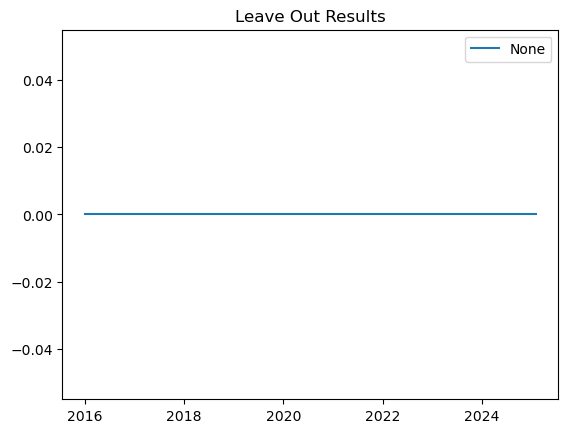

  Metric  RAGU_diff
0   None        0.0


In [55]:
leave_out_results_dict = dict()
waterfall_df = pd.DataFrame()
for leave_out in leave_out_list:
    RAGU_diff = np.abs(all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score).mean()
    waterfall_df[leave_out] = all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score
    leave_out_results_dict[leave_out] = RAGU_diff
    plt.plot(all_leave_out_df.loc['None'].vintage.apply(vintage_to_float), all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score, label=leave_out)
plt.title("Leave Out Results")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()
print(pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff'))
waterfall_df.index = all_leave_out_df.loc['None'].vintage
#waterfall_df

In [56]:
leave_out_df#[np.array(leave_out_df.reset_index().vintage.apply(vintage_to_float)>=2022)]

,index,amt_financed_x,loss_multiplier,recovery_unadjusted_multiplier,ltv,bbvalue,ltv_realization_factor,recovery_100_ltv_multiplier,recovery_multiplier,model_score,amt_financed_y,est_unit_loss,unit_loss_score,ms_original,baselined_recovery,baselined_unadjusted_recovery,baselined_100_ltv_recovery,ms_gla,ms_exclude_ltv,ms_100_ltv,ragu_score,leave_out
vintage,,,,,,,,,,,,,,,,,,,,,,
2016 M01,non_kmxent,24222749.14,NaN,0.421801,2.054703,NaN,NaN,0.0,0.0,NaN,NaN,0.5,128.5084,129.365134,0.0,0.97911,0.0,128.5084,127.942229,128.5084,128.5084,None
2016 M02,non_kmxent,33617839.78,NaN,0.41883,1.981513,NaN,NaN,0.0,0.0,NaN,NaN,0.5,127.581588,128.218012,0.0,0.972214,0.0,127.581588,126.839228,127.581588,127.581588,None
2016 M03,non_kmxent,40192730.84,NaN,0.421459,1.990942,NaN,NaN,0.0,0.0,NaN,NaN,0.5,127.587996,128.341163,0.0,0.978318,0.0,127.587996,127.005032,127.587996,127.587996,None
2016 M04,non_kmxent,28188291.62,NaN,0.423208,2.025359,NaN,NaN,0.0,0.0,NaN,NaN,0.5,129.009295,129.78816,0.0,0.982377,0.0,129.009295,128.528207,129.009295,129.009295,None
2016 M05,non_kmxent,27547922.13,NaN,0.422653,1.986544,NaN,NaN,0.0,0.0,NaN,NaN,0.5,129.856814,130.573803,0.0,0.981088,0.0,129.856814,129.33784,129.856814,129.856814,None
2016 M06,non_kmxent,27403315.51,NaN,0.424018,1.952342,NaN,NaN,0.0,0.0,NaN,NaN,0.5,129.17079,130.046969,0.0,0.984256,0.0,129.17079,128.739646,129.17079,129.17079,None
2016 M07,non_kmxent,26376537.28,NaN,0.425827,1.962463,NaN,NaN,0.0,0.0,NaN,NaN,0.5,129.762924,130.730847,0.0,0.988457,0.0,129.762924,129.444002,129.762924,129.762924,None
2016 M08,non_kmxent,30260183.4,NaN,0.428218,1.965835,NaN,NaN,0.0,0.0,NaN,NaN,0.5,130.437007,131.335306,0.0,0.994007,0.0,130.437007,130.269636,130.437007,130.437007,None
2016 M09,non_kmxent,27432633.86,NaN,0.430219,1.985024,NaN,NaN,0.0,0.0,NaN,NaN,0.5,131.269259,131.91899,0.0,0.99865,0.0,131.269259,131.231148,131.269259,131.269259,None


C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_7480\3882856466.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1))


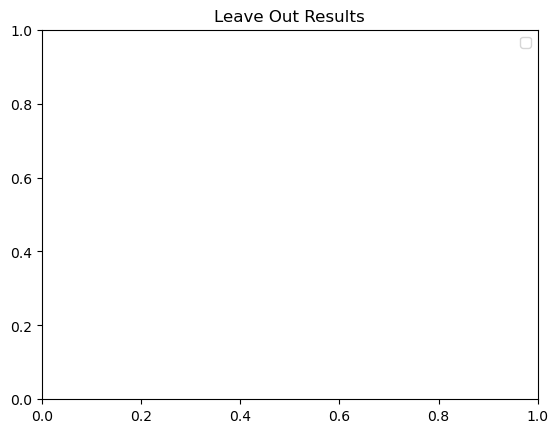

,Metric,RAGU_diff


In [57]:
leave_out_results_dict = dict()
for leave_out in leave_out_list:
    plt_df = waterfall_df[np.array(waterfall_df.reset_index().vintage.apply(vintage_to_float)>=2020)].reset_index()
    if (np.abs(plt_df['None'] - plt_df[leave_out])).mean() < 0.05:
        continue
    plt.plot(plt_df.vintage.apply(vintage_to_float), smooth(np.abs(plt_df['None'] - plt_df[leave_out])), label=leave_out)
    leave_out_results_dict[leave_out] = np.abs(plt_df['None'] - plt_df[leave_out]).mean()
plt.title("Leave Out Results")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()
pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff')

In [17]:
store_pickle(vintages_dict, 'vintages_dict_pickle')

In [18]:
pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff')

NameError: name 'leave_out_results_dict' is not defined

# Export results to an Excel for manual inputs

In [56]:
import openpyxl
import pyodbc
import warnings
import pandas as pd
import datetime
import numpy as np
import re
import os
import copy

In [57]:
def excel_cell_to_index(cell_name):
    """
    Converts a cell name to its index; for example, 'B2' becomes (2, 2), since B is the second letter of the alphabet.
    """
    # Extract the column part from the cell name
    col_str = ''.join(filter(str.isalpha, cell_name)).upper()
    # Convert column letters to column index
    col_index = 0
    for i, char in enumerate(col_str):
        col_index = col_index * 26 + (ord(char) - ord('A')) + 1
    # Extract the row part from the cell name
    row_str = ''.join(filter(str.isdigit, cell_name))
    # Convert row string to row index
    row_index = int(row_str)
    return row_index, col_index
def overwrite_values(df, start_cell, worksheet):
    """
    Overwrites values in the given worksheet with the values in the given DataFrame, starting at the given cell name start_cell.
    """
    # Get the size of the DataFrame
    num_rows, num_cols = df.shape
    # Get starting cell indices
    start_cell_row, start_cell_col = excel_cell_to_index(start_cell)
    # Replace the data in the worksheet with the DataFrame
    for row in range(num_rows):
        for col in range(num_cols):
            cell = worksheet.cell(row=row+start_cell_row, column=col+start_cell_col)
            cell.value = df.iloc[row, col]
    return worksheet
def read_excel_selection(start_cell, end_cell, worksheet):
    """
    Converts a section of the worksheet to a Pandas DataFrame.
    """
    start_row, start_col = excel_cell_to_index(start_cell)
    end_row, end_col = excel_cell_to_index(end_cell)
    # Read data from the selected range into a list of lists
    data = []
    for row in range(start_row, end_row + 1):
        row_data = []
        for col in range(start_col, end_col + 1):
            cell = worksheet.cell(row=row, column=col)
            row_data.append(cell.value)
        data.append(row_data)
    return pd.DataFrame(data)
# This function returns the value contained within a given cell
excel_lookup = lambda cell: workbook[re.search(r'=(.*?)!', cell.value).group(1)][re.search(r'!(.*)', cell.value).group(1)]

In [58]:
# Be sure to rerun this code after hitting ctrl+s in the Excel document.
workbook = openpyxl.load_workbook('RAGU Scores Updated QMW POS - current.xlsx')

# Save Data Tables

### NonKMXENT

In [59]:
worksheet = workbook[f'Data Tables ({granularity.upper()})']

In [60]:
worksheet

<Worksheet "Data Tables (M)">

In [61]:
for lob, cell in zip(('AN', 'FRN', 'STG', 'non_kmxent'), ('B2', 'B20', 'B29', 'B47')):
    result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
    result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
    result_df = result_yearly_df.drop('amt_financed_x')
    for year in range(2016, 2020):
        year = str(year)
        metric_dict = dict()
        if granularity=='q':
            vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)]
        elif granularity == 'm':
            vintages_in_year = [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
        
        for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
            metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
        result_yearly_df[year] = pd.Series(metric_dict)
    result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
    result_yearly_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
    full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
    differences_df = full_result_df.copy()
    differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
    differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
    differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
    differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
    differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
    differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
    differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
    xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
    worksheet = overwrite_values(xlsx_df, cell, worksheet)

In [62]:
correct_vintage_order = list(xlsx_df.columns)

### ENT, FLD

In [63]:
for lob, cell in zip(('ENT', 'FLD'), ('F38', 'F11')):
    result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
    result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
    result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
    full_result_df = result_df.copy()
    differences_df = full_result_df.copy()
    differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
    differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
    differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
    differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
    differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
    differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
    differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
    xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
    worksheet = overwrite_values(xlsx_df, cell, worksheet)

In [64]:
# for lob, cell in zip(('ENT', 'FLD'), ('F38', 'F11')):
#     result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
#     result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
#     result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
#     result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
#     full_result_df = result_df.copy()
#     differences_df = full_result_df.copy()
#     differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
#     differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
#     differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
#     differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
#     differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
#     differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
#     differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
#     xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T

In [65]:
# scratch = all_df_no_dropout.loc['ENT'][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']]#.reset_index(drop=True).set_index('vintage').T.copy()
# scratch.to_csv("scratch.csv")

### KMX

In [66]:
lob = 'KMX'
result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
result_df = result_yearly_df.drop('amt_financed_x')
for year in range(2016, 2020):
    year = str(year)
    metric_dict = dict()
    vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)] if granularity=='q' else [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
    for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
        metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
    result_yearly_df[year] = pd.Series(metric_dict)
result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
result_yearly_df.index = ['Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df.index = ['Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
differences_df = full_result_df.copy()
differences_df.loc['Mountain3 Score'] = full_result_df.loc['Mountain3 Score'] - full_result_df.loc['Contract Model Score']
differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['Mountain3 Score']
differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
xlsx_df = differences_df.T[['Contract Model Score', 'Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
xlsx_df = xlsx_df[correct_vintage_order]
print(xlsx_df)
worksheet = overwrite_values(xlsx_df, 'B56', worksheet)

vintage                                     2016        2017        2018  \
Contract Model Score                  136.593269  139.090002  137.775851   
Mountain3 Score                         0.000000    0.000000    0.000000   
Gross Loss Adjustments                  1.604326    2.515617    2.438410   
Recovery Adjustments (Excluding LTV)    0.387945    0.188731   -0.014484   
LTV Adjustments                        -0.387945   -0.188731    0.014484   
RAGU Score                            138.197594  141.605619  140.214261   
LTV                                     1.556378    1.567065    1.581520   

vintage                                     2019    2020 M01    2020 M02  \
Contract Model Score                  136.875284  136.070894  136.072001   
Mountain3 Score                         0.000000    0.000000    0.000000   
Gross Loss Adjustments                  2.461330    2.413387    2.375306   
Recovery Adjustments (Excluding LTV)   -0.100194   -1.203092   -1.368760   
LTV Adjustm

### POS

In [67]:
lob = 'POS'
result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
result_df = result_yearly_df.drop('amt_financed_x')
for year in range(2016, 2020):
    year = str(year)
    metric_dict = dict()
    vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)] if granularity=='q' else [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
    for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
        metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
    result_yearly_df[year] = pd.Series(metric_dict)
result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
result_yearly_df.index = ['Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df.index = ['Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
differences_df = full_result_df.copy()
differences_df.loc['Modern Score'] = full_result_df.loc['Modern Score'] - full_result_df.loc['Contract Model Score']
differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['Modern Score']
differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
xlsx_df = differences_df.T[['Contract Model Score', 'Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
worksheet = overwrite_values(xlsx_df, 'B65', worksheet)

# Distribution Data

In [36]:
with pyodbc.connect("DSN=Redshift_prod") as conn:
    with open("distribution_query_temp.txt", "r") as file:
        temp_table_queries = file.read()
        conn.execute(temp_table_queries.strip())
        distribution_df = run_sql('distribution_query_current.txt', connection=conn)
distribution_df  = distribution_df.pivot(index = 'roa_dealer_group',columns = 'vintage', values = 'distribution')

worksheet = worksheet = workbook['distribution_rolledup']
worksheet = overwrite_values(distribution_df,'B3', worksheet)

In [37]:
distribution_df.head()

vintage,2016,2017,2018,2019,20201,20202,20203,20204,20211,20212,20213,20214,20221,20222,20223,20224,20231,20232,20233,20234,20241,20242,20243,20244,20251
roa_dealer_group,,,,,,,,,,,,,,,,,,,,,,,,,
AN,0.136329,0.144379,0.111739,0.061138,0.057628,0.059112,0.048654,0.049697,0.048043,0.053450,0.041309,0.043412,0.039799,0.042595,0.049513,0.044590,0.046034,0.048740,0.049392,0.059192,0.059999,0.060395,0.052556,0.053145,0.057059
ENT,NaN,NaN,NaN,0.003504,0.076819,0.100272,0.087058,0.111206,0.133277,0.175045,0.152098,0.140821,0.129625,0.124757,0.124891,0.187172,0.207633,0.190607,0.163535,0.171031,0.154145,0.139879,0.136669,0.151945,0.157865
FLD,NaN,NaN,NaN,0.015148,0.050613,0.040833,0.031133,0.017144,0.021179,0.040948,0.040064,0.032455,0.024748,0.025069,0.028075,0.026197,0.014230,0.021409,0.023341,0.025230,0.032670,0.047948,0.036515,0.035717,0.043338
FRN,0.016158,0.027996,0.017103,0.016819,0.045965,0.065478,0.070237,0.080994,0.070801,0.104654,0.104392,0.122382,0.105801,0.114287,0.128540,0.095479,0.059170,0.081173,0.094753,0.165139,0.179093,0.205544,0.186865,0.200703,0.181666
KMX,0.622022,0.660488,0.681063,0.728163,0.641369,0.608927,0.652297,0.641473,0.633789,0.518795,0.561622,0.554715,0.608044,0.598350,0.591039,0.592437,0.637967,0.615265,0.614259,0.487606,0.486058,0.414471,0.469552,0.440736,0.444564


# $t_{-1}$ Table

In [68]:
worksheet = workbook['t-1 Data Table']
run_query = False
if run_query or run_every_query:
    t_1_table = run_sql('select * from sandbox.t_1', filename_is_query=True)
    store_pickle(t_1_table, 't_1_table_pickle')
else:
    t_1_table = get_pickle('t_1_table_pickle')
latest_t_1 = pd.DataFrame(columns=t_1_table.columns)
for lob in t_1_table.roa_dealer_group.unique():
    latest_t_1 = pd.concat([latest_t_1, t_1_table[t_1_table['lookup']==(lob+str(t_1_table[t_1_table.roa_dealer_group==lob].rowid.max()))]])
latest_t_1 = latest_t_1.sort_values('lookup').set_index('roa_dealer_group').loc[['AN', 'ENT', 'FLD', 'FRN', 'KMX', 'STG']]
worksheet = overwrite_values(latest_t_1, 'B2', worksheet)

C:\Users\gaura.sinha\AppData\Local\Temp\ipykernel_18892\1305636891.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  latest_t_1 = pd.concat([latest_t_1, t_1_table[t_1_table['lookup']==(lob+str(t_1_table[t_1_table.roa_dealer_group==lob].rowid.max()))]])


# Put Leave Out Analysis Waterfalls in Excel

In [ ]:
worksheet = workbook['Waterfall Tables']
waterfall_df_dict = dict()
for lob, cell, lob_type in zip(['AN', 'FRN', 'STG', 'FLD', 'KMX', 'ENT'], 
                     ['B3', 'B48', 'B92', 'B135', 'B190', 'B164'],
                     ['non_kmxent']*4+['KMX', 'ENT']):
    all_leave_out_df = pd.DataFrame()
    for leave_out in leave_out_list:
        leave_out_df = pd.DataFrame()
        for i in full_df_list_dict_dict[leave_out][lob_type]:
            if (lob=='FLD' and 'FLD' not in i.index) or (lob=='ENT' and 'ENT' not in i.index):
                continue
            leave_out_df = pd.concat([leave_out_df, pd.DataFrame(i.loc[lob]).T])
        leave_out_df['leave_out'] = leave_out
        leave_out_df = leave_out_df.reset_index().set_index('vintage')
        all_leave_out_df = pd.concat([all_leave_out_df, leave_out_df])
    all_leave_out_df = all_leave_out_df.reset_index().set_index('leave_out')

    waterfall_df = pd.DataFrame()
    for leave_out in leave_out_list:
        waterfall_df[leave_out] = all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score
    waterfall_df.index = all_leave_out_df.loc['None'].vintage
    waterfall_df_dict[lob] = waterfall_df
    worksheet = overwrite_values(waterfall_df, cell, worksheet)

In [69]:
workbook.save('RAGU Scores Updated QMW POS - current.xlsx')

In [ ]:
mmi_lookup_df = pd.read_csv('../../Downloads/mmi_index_2019seasonality.csv').rename(columns={'mmi_2019_seasonality_index':'mmi'})
mmi_lookup_df['month'] = mmi_lookup_df.month_start.astype(str).str[:4] + '-' + mmi_lookup_df.month_start.astype(str).str[4:6]
mmi_lookup_df = mmi_lookup_df.drop(columns='month_start')
mmi_lookup_df

In [ ]:
pd.__version__

In [ ]:
pd.get_option('mode.copy_on_write')

In [120]:
all_leave_out_df

,vintage,index,amt_financed_x,loss_multiplier,recovery_unadjusted_multiplier,ltv,bbvalue,ltv_realization_factor,recovery_100_ltv_multiplier,recovery_multiplier,model_score,amt_financed_y,est_unit_loss,unit_loss_score,ms_original,baselined_recovery,baselined_unadjusted_recovery,baselined_100_ltv_recovery,ms_gla,ms_exclude_ltv,ms_100_ltv,ragu_score
leave_out,,,,,,,,,,,,,,,,,,,,,,
None,2019 Q4,ENT,6911022.45,1.008642,0.458652,1.506303,13727.730559,0,0,0,128.242403,6911022.45,0.5,128.045995,128.242403,0,0.99707,0,128.045995,127.959971,128.045995,128.045995
None,2020 Q1,ENT,43073152.54,0.986526,0.460056,1.468607,12807.462223,0,0,0,132.383068,43073152.54,0.5,132.689294,132.383068,0,1.000121,0,132.689294,132.692999,132.689294,132.689294
None,2020 Q2,ENT,47562355.68,0.983094,0.461953,1.444272,12552.012109,0,0,0,133.228641,47596497.42,0.5,133.61286,133.228641,0,1.004247,0,133.61286,133.743914,133.61286,133.61286
None,2020 Q3,ENT,48067286.34,0.978206,0.462508,1.266616,15426.735029,0,0,0,136.301658,48083505.18,0.5,136.796982,136.301658,0,1.005453,0,136.796982,136.969475,136.796982,136.796982
None,2020 Q4,ENT,49972124.76,1.002092,0.46231,1.362132,15190.505499,0,0,0,135.382425,50003007.9,0.5,135.334883,135.382425,0,1.005022,0,135.334883,135.491992,135.334883,135.334883
None,2021 Q1,ENT,91042836.98,0.989445,0.462297,1.347777,14766.288071,0,0,0,133.835704,91042836.98,0.5,134.07558,133.835704,0,1.004994,0,134.07558,134.230337,134.07558,134.07558
None,2021 Q2,ENT,128703304.92,0.989585,0.457792,1.247573,19220.025562,0,0,0,131.874898,128733743.34,0.5,132.111607,131.874898,0,0.9952,0,132.111607,131.966466,132.111607,132.111607
None,2021 Q3,ENT,96939885.38,0.987985,0.450766,1.324637,20320.145688,0,0,0,131.135692,96939885.38,0.5,131.408756,131.135692,0,0.979926,0,131.408756,130.814219,131.408756,131.408756
None,2021 Q4,ENT,74023051.55,0.989441,0.446639,1.35702,20269.316326,0,0,0,129.472303,74050276.87,0.5,129.712289,129.472303,0,0.970955,0,129.712289,128.870931,129.712289,129.712289


In [74]:
scratch = ula_df_total.loc[(ula_df_total['lob']=='KMX') & (ula_df_total['vintage']=='2025 M02')]
scratch.head()

,account_number,book_date,book_week,book_vintage,app_date,bbvalue,dealer_number,sale_price,frni_flag,amt_financed,cash_down,tradein_value,mileage,cd_model_score,total_income,pti,make,model_year,vin,lob,day_of_week,secured_credit_card,specialty_dealer,employed_months,fico_score,vantage_score,state,pull_type,existing_dq_count,pct_auth_tradelines,open_tl,prev_co_count,lob_or_bucket,apr_bucket,fico_adjustment_flag,mtn_model,mtn_3_1_flag,vehicle_age,continuous_vehicle_age,loss_ratio,method,dealer_level,no_manual_dealer_level,pricing_scalar,dealer_filter_a,dealer_filter_b,ent_fld_flag,small_amt_financed_flag,zero_cash_down_flag,high_mileage_vehicle_flag,high_pti_flag,car_make_penalty_flag,car_make_benefit_flag,theft_risk_flag,mcy_low_mileage_flag,weekend_flag,weekday_flag,secured_credit_flag,seasonal_employment_flag,waiter_employment_flag,high_cash_down_echopark_flag,nonkmx_auth_tradelines_flag,prev_co_flag,null_fico_w_vantage_flag,null_fico_null_vantage_flag,pricing_change_flag,job_time_flag,low_fico_flag,high_model_score_flag,low_vantage_flag,louisiana_flag,normal_pti_flag,high_pti_tier_1_flag,high_pti_tier_2_flag,high_pti_tier_3_flag,existing_dq_flag,kmx_auth_tradelines_flag,low_bureau_flag,soft_pull_flag,cd_perc_flag,open_tl_flag,narrowed_soft_pull_flag,vintage,employment_type_code
89,90124915702,2025-02-27,9,current,2025-02-26,17525.0,7175,20998.00,0,23778.24,3500.00,0.0,31766,147.0,4182.49,0.110150,CHE,2023,3GNAXKEG4PS193801,KMX,3.0,1,not specialty,8.0,0,588,FL,None,0,0.0,0,0,KMX,A,0,MTN3.1,True,2.0,1.416667,NaN,NaN,NaN,NaN,1.0,False,False,False,False,False,False,False,False,False,False,False,False,True,1,False,False,False,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,0,False,2025 M02,0
301,90124916260,2025-02-27,9,current,2025-02-26,14062.5,7164,18998.00,0,18981.00,2199.40,0.0,103433,136.0,3687.02,0.148299,HON,2020,1HGCV1F3XLA044240,KMX,3.0,1,not specialty,21.0,0,564,CA,None,1,0.0,0,0,KMX,D,0,,False,5.0,4.416667,NaN,NaN,NaN,NaN,1.0,False,False,False,False,False,False,False,False,True,False,False,False,True,1,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,0,False,2025 M02,0
454,90124913405,2025-02-25,9,current,2025-02-23,7175.0,7091,14592.25,0,15505.00,3299.00,0.0,99215,138.0,3465.27,0.108119,TOY,2016,5YFBURHE8GP473176,KMX,0.0,1,not specialty,21.0,0,521,CA,softpull,0,0.0,0,0,KMX,D,0,,False,9.0,8.416667,NaN,NaN,NaN,NaN,1.0,False,False,False,False,False,False,False,False,True,False,False,True,False,1,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,0,False,2025 M02,0
633,90124899616,2025-02-03,6,current,2025-02-01,21325.0,11707,28998.00,0,31969.00,3499.94,0.0,59273,150.0,2667.00,0.256355,RAM,2021,3C6RR7KT1MG587735,KMX,6.0,0,not specialty,4.0,0,609,CO,softpull,0,0.0,0,0,KMX,B,0,,False,4.0,3.416667,NaN,NaN,NaN,NaN,1.0,False,False,False,False,False,False,False,False,False,False,False,True,False,0,False,False,False,False,False,True,False,True,True,False,True,False,False,False,False,True,False,False,False,False,True,False,0,False,2025 M02,0
866,90124910247,2025-02-20,8,current,2025-02-19,17500.0,26264,22998.00,0,24961.12,2000.00,0.0,47632,131.0,6428.92,0.101411,DOD,2022,2C3CDXBG2NH234720,KMX,3.0,0,not specialty,53.0,0,511,AL,softpull,1,0.0,0,0,KMX,D,0,MTN3.1,True,3.0,2.416667,NaN,NaN,NaN,NaN,1.0,False,False,False,False,False,False,False,False,False,False,False,False,True,0,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False,0,False,2025 M02,0
